In [1]:
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns

## Config

In [5]:
path = Path('/home/casadoj/Data/CAMELS-ES/v2_0_0/preprocessing/timeseries/meteo')

## Data

In [6]:
rename_cols = {
    'avgtemp_mean': 'ta_mean',
    'e0_mean': 'e0_mean',
    'precipitation_mean': 'pr_mean',
}

In [7]:
# list station IDs
IDs = [int(file.stem) for file in (path / 'ROCIO-IBEB').glob('*.parquet')]

In [ ]:
summary = {}
for ID in tqdm(IDs):
    timeseries = pd.DataFrame()
    for meteo in ['CERRA', 'EMO1', 'ROCIO-IBEB']:

        try:
            df = pd.read_parquet(path / meteo / f'{ID}.parquet').loc[ID]
        except:
            continue

        # treat columns
        df.rename(columns=rename_cols, inplace=True, errors='ignore')
        df = df[rename_cols.values()]
        df.columns = [col.split('_')[0] + '_' + meteo for col in df.columns]

        # treat index
        df.index = df.index.normalize()

        timeseries = pd.concat([timeseries, df], axis=1, sort=True)

    timeseries.sort_index(axis=1, inplace=True)
    timeseries.dropna(axis=0, how='any', inplace=True)

    # summarize
    summary[ID] = timeseries.mean()

# consolidate summary
summary = pd.DataFrame.from_dict(summary).T
summary.sort_index(axis=0, inplace=True)

  0%|          | 0/1116 [00:00<?, ?it/s]

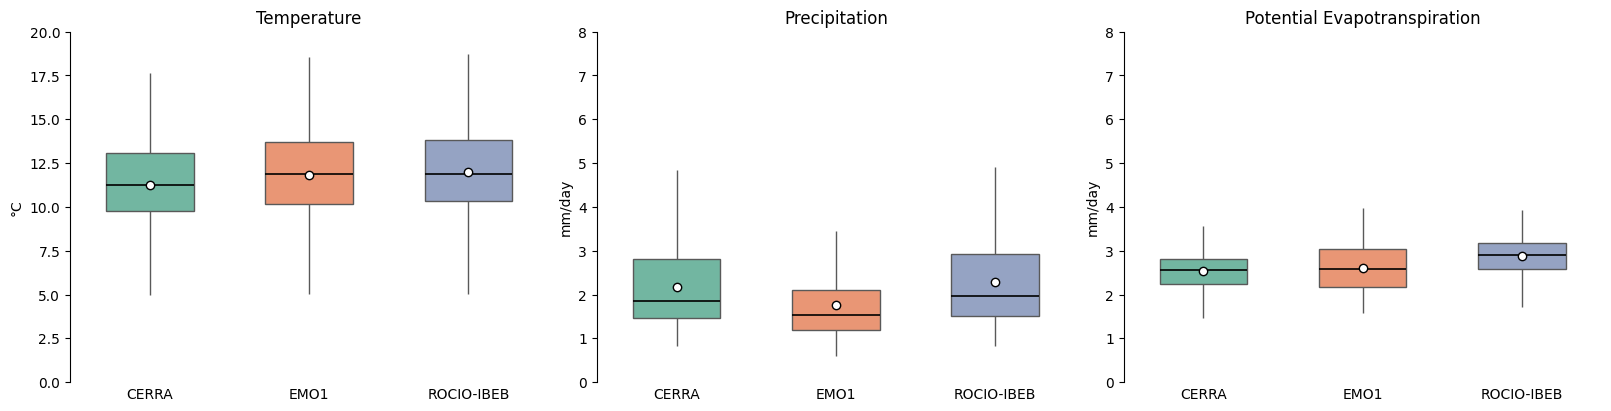

In [33]:
variables = {
    "ta": ("Temperature", "°C", (0, 20)),
    "pr": ("Precipitation", "mm/day", (0, 8)),
    "e0": ("Potential Evapotranspiration", "mm/day", (0, 8)),
}

fig, axes = plt.subplots(
    ncols=len(variables), 
    figsize=(16, 4),
    constrained_layout=True
)

for ax, (var, (title, unit, ylim)) in zip(axes, variables.items()):
    cols = [col for col in summary.columns if col.startswith(var)]
    data = summary[cols].copy()
    data.columns = [col.split('_')[1] for col in cols]
    sns.boxplot(
        data=data,
        width=.55,
        palette='Set2', 
        showfliers=False,
        showmeans=True,
        showcaps=False,
        medianprops={'color': 'k', 'linewidth': 1.2},
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6,
        },
        ax=ax
    )
    ax.set(
        title=title,
        ylabel=unit,
        ylim=ylim
    )
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.tick_params(axis="x", length=0)
